In [3]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset
import torch

c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
data_dir = os.getenv("DATA_DIR")
datasplits_dir = os.getenv("DATASPLITS_DIR")
embeddings_dir = os.getenv("EMBEDDINGS_DIR")

text_train_path = os.path.join(datasplits_dir, "text_train.tsv")
text_val_path = os.path.join(datasplits_dir, "text_val.tsv")
text_test_path = os.path.join(datasplits_dir, "text_test.tsv")

train_bert_path = os.path.join(embeddings_dir, "train_bert.npy")
val_bert_path = os.path.join(embeddings_dir, "val_bert.npy")
test_bert_path = os.path.join(embeddings_dir, "test_bert.npy")

train_roberta_path = os.path.join(embeddings_dir, "train_roberta.npy")
val_roberta_path = os.path.join(embeddings_dir, "val_roberta.npy")
test_roberta_path = os.path.join(embeddings_dir, "test_roberta.npy")

train_bertweet_path = os.path.join(embeddings_dir, "train_bertweet.npy")
val_bertweet_path = os.path.join(embeddings_dir, "val_bertweet.npy")
test_bertweet_path = os.path.join(embeddings_dir, "test_bertweet.npy")

In [6]:
train_bert = np.load(train_bert_path)
val_bert = np.load(val_bert_path)
test_bert = np.load(test_bert_path)

train_roberta = np.load(train_roberta_path)
val_roberta = np.load(val_roberta_path)
test_roberta = np.load(test_roberta_path)

train_bertweet = np.load(train_bertweet_path)
val_bertweet = np.load(val_bertweet_path)
test_bertweet = np.load(test_bertweet_path)

In [7]:

text_train_df = pd.read_csv(text_train_path, sep='\t')
text_val_df = pd.read_csv(text_val_path, sep='\t')
text_test_df = pd.read_csv(text_test_path, sep='\t')

print(f"text train set size: {len(text_train_df)}")
print(f"text val set size: {len(text_val_df)}")
print(f"text test set size: {len(text_test_df)}")

text_train_df.head()

text train set size: 11240
text val set size: 2409
text test set size: 2409


,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet
0,Trucking Companies Houston's Lifeline Surges I...,informative,rescue_volunteering_or_donation_effort,Trucking Companies Houston's Lifeline Surges I...,Trucking Companies Houston's Lifeline Surges I...
1,#Hurricane #Harvey damaged #ExxonMobil refiner...,informative,infrastructure_and_utility_damage,Hurricane Harvey damaged ExxonMobil refineries...,#Hurricane #Harvey damaged #ExxonMobil refiner...
2,Witness in former Mora superintendent's forger...,not_informative,not_humanitarian,Witness in former Mora superintendent's forger...,Witness in former Mora superintendent's forger...
3,Mexico earthquake: Many children killed at pri...,informative,affected_individuals,Mexico earthquake: Many children killed at pri...,Mexico earthquake: Many children killed at pri...
4,@KrollOntrack is offering discounted recoverie...,informative,rescue_volunteering_or_donation_effort,is offering discounted recoveries for hurrican...,@KrollOntrack is offering discounted recoverie...


In [8]:
#Task 1: Binary (text_info)
le_info = LabelEncoder()
le_info.fit(text_train_df["text_info"])  # Adatta solo sul train

train_labels_task1 = le_info.transform(text_train_df["text_info"])
val_labels_task1 = le_info.transform(text_val_df["text_info"])
test_labels_task1 = le_info.transform(text_test_df["text_info"])

#Task 2: Multiclasse (text_human)
le_human = LabelEncoder()
le_human.fit(text_train_df["text_human"])

train_labels_task2 = le_human.transform(text_train_df["text_human"])
val_labels_task2 = le_human.transform(text_val_df["text_human"])
test_labels_task2 = le_human.transform(text_test_df["text_human"])

#Mapping classi e label
print("Task 1 classes:", dict(zip(le_info.classes_, le_info.transform(le_info.classes_))))
print("Task 2 classes:", dict(zip(le_human.classes_, le_human.transform(le_human.classes_))))

Task 1 classes: {'informative': 0, 'not_informative': 1}
Task 2 classes: {'affected_individuals': 0, 'infrastructure_and_utility_damage': 1, 'not_humanitarian': 2, 'other_relevant_information': 3, 'rescue_volunteering_or_donation_effort': 4}


In [22]:
def create_mlp(input_dim, output_dim, is_binary):
    
    input = keras.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(input)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(output_dim, activation='sigmoid' if is_binary else 'softmax')(x)
    model = keras.Model(inputs=input, outputs=output)

    model.compile(
        loss='binary_crossentropy' if is_binary else 'categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

In [23]:
def plot_training_history(history, title="Model Training"):
    """
    Plot accuracy and loss curves for training and validation.

    Parameters:
        history (History): Keras History object returned by model.fit()
        title (str): Title prefix for the plots
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [24]:
def evaluate_task(name, y_test, y_pred_labels, task=1, label_encoder=None):   
    is_binary = (task == 1)
    
    # 📊 Report metriche
    acc = accuracy_score(y_test, y_pred_labels)
    avg_type = 'binary' if is_binary else 'macro'
    prec = precision_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    rec = recall_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    f1 = f1_score(y_test, y_pred_labels, average=avg_type, zero_division=0)

    print(f"\n📊 Results for {name.upper()} - Task {task}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # 🧩 Matrice di confusione
    if label_encoder:
        display_labels = label_encoder.classes_
    else:
        display_labels = None

    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues')
    if not is_binary:
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

    plt.title(f"Confusion Matrix - {name.upper()} - Task {task}", )
    plt.show()

In [35]:
def train_and_evaluate(name, X_train, y_train, X_val, y_val, X_test, y_test, task=1, label_encoder=None):
    is_binary = (task == 1)
    y_train_enc = y_train if is_binary else to_categorical(y_train)
    y_val_enc = y_val if is_binary else to_categorical(y_val)
    
    model = create_mlp(X_train.shape[1], 1 if is_binary else y_train_enc.shape[1], is_binary)
    print(f"\n🚀 Training MLP on {name.upper()} embeddings (Task {task})")

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=50,
        batch_size=32,
        callbacks=[es],
    )

    plot_training_history(history, title=f"{name.upper()} - Task {task}")
    
    y_pred = model.predict(X_test)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten() if is_binary else np.argmax(y_pred, axis=1)

    evaluate_task(name, y_test, y_pred_labels, task, label_encoder)

In [36]:
embedding_sets = {
    "bert": {
        "train": train_bert,
        "val": val_bert,
        "test": test_bert
    },
    "roberta": {
        "train": train_roberta,
        "val": val_roberta,
        "test": test_roberta
    },
    "bertweet": {
        "train": train_bertweet,
        "val": val_bertweet,
        "test": test_bertweet
    }
}


🚀 Training MLP on BERT embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7475 - loss: 0.5195 - val_accuracy: 0.8227 - val_loss: 0.4129
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7958 - loss: 0.4419 - val_accuracy: 0.8261 - val_loss: 0.4005
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8078 - loss: 0.4301 - val_accuracy: 0.8290 - val_loss: 0.3972
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8167 - loss: 0.4233 - val_accuracy: 0.8315 - val_loss: 0.3911
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8138 - loss: 0.4184 - val_accuracy: 0.8281 - val_loss: 0.3872
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8161 - loss: 0.4132 - val_accuracy: 0.8194 - val_loss: 0.4130
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8169 - loss: 0.4139 - val_accuracy: 0.8257 - val_loss: 0.4041
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accura

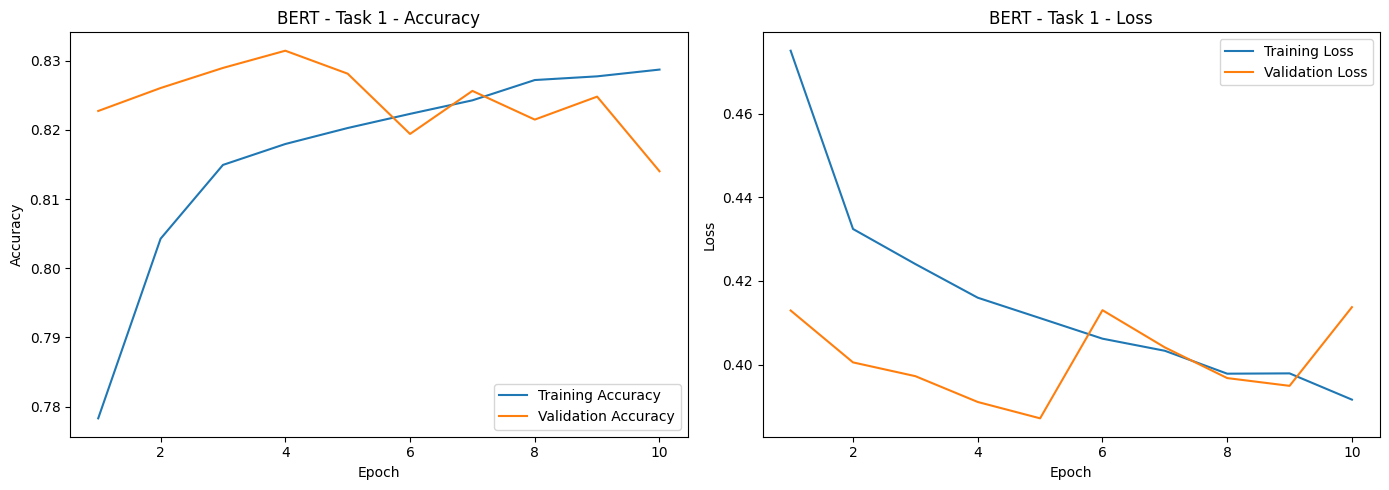

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Results for BERT - Task 1
Accuracy : 0.8086
Precision: 0.7018
Recall   : 0.5652
F1-score : 0.6261


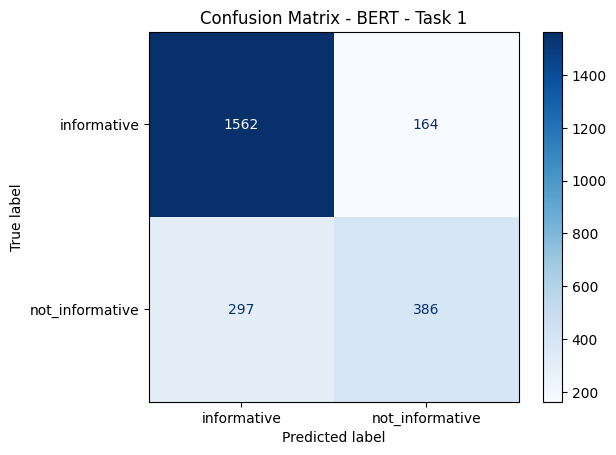


🚀 Training MLP on BERT embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4902 - loss: 1.2564 - val_accuracy: 0.6210 - val_loss: 0.9877
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6060 - loss: 1.0020 - val_accuracy: 0.6297 - val_loss: 0.9499
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6228 - loss: 0.9551 - val_accuracy: 0.6418 - val_loss: 0.8977
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6349 - loss: 0.9264 - val_accuracy: 0.6480 - val_loss: 0.8766
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6424 - loss: 0.9102 - val_accuracy: 0.6418 - val_loss: 0.9065
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6497 - loss: 0.8852 - val_accuracy: 0.6476 - val_loss: 0.9076
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6531 - loss: 0.8675 - val_accuracy: 0.6472 - val_loss: 0.9338
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accura

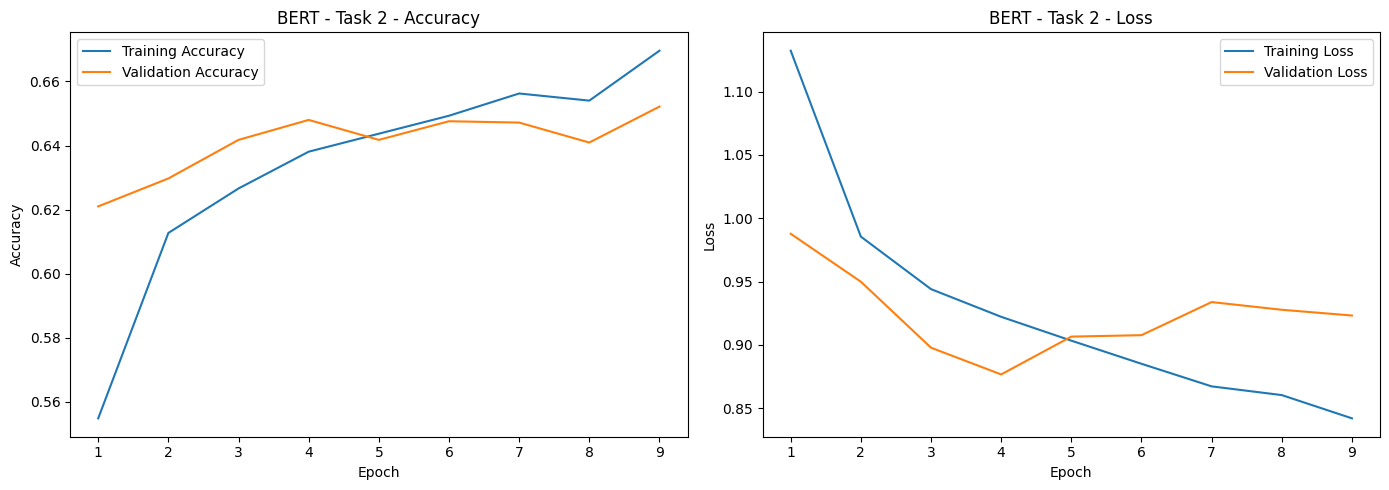

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Results for BERT - Task 2
Accuracy : 0.6397
Precision: 0.6507
Recall   : 0.5428
F1-score : 0.5657


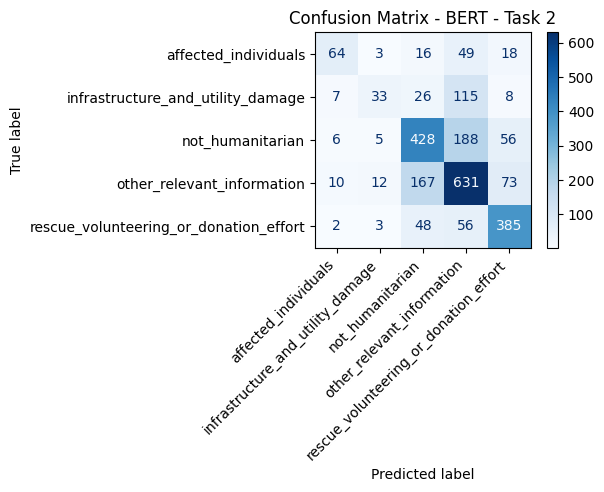

In [37]:
name = "bert"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)


🚀 Training MLP on ROBERTA embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7280 - loss: 0.5674 - val_accuracy: 0.8236 - val_loss: 0.4096
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8153 - loss: 0.4342 - val_accuracy: 0.8443 - val_loss: 0.3889
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8182 - loss: 0.4249 - val_accuracy: 0.8302 - val_loss: 0.4020
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8210 - loss: 0.4197 - val_accuracy: 0.8435 - val_loss: 0.3846
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8238 - loss: 0.4141 - val_accuracy: 0.8423 - val_loss: 0.3790
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8280 - loss: 0.4046 - val_accuracy: 0.8439 - val_loss: 0.3787
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8286 - loss: 0.4019 - val_accuracy: 0.8435 - val_loss: 0.3786
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc

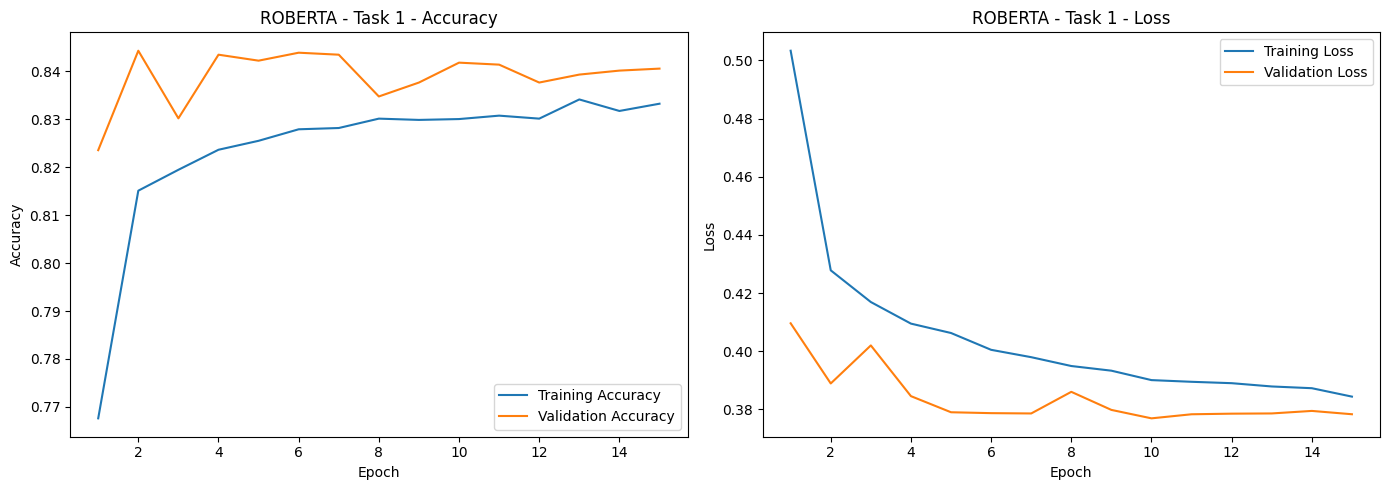

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

📊 Results for ROBERTA - Task 1
Accuracy : 0.8227
Precision: 0.7581
Recall   : 0.5505
F1-score : 0.6378


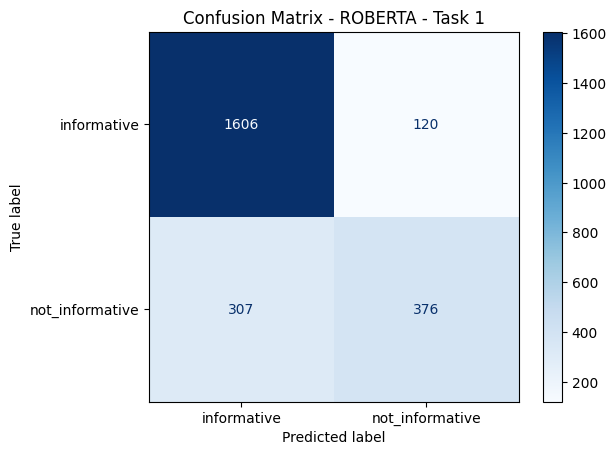


🚀 Training MLP on ROBERTA embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4494 - loss: 1.3221 - val_accuracy: 0.6231 - val_loss: 0.9740
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6116 - loss: 0.9858 - val_accuracy: 0.6218 - val_loss: 0.9447
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6312 - loss: 0.9415 - val_accuracy: 0.6326 - val_loss: 0.9270
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6496 - loss: 0.8979 - val_accuracy: 0.6455 - val_loss: 0.9335
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6535 - loss: 0.8751 - val_accuracy: 0.6596 - val_loss: 0.9004
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6627 - loss: 0.8549 - val_accuracy: 0.6596 - val_loss: 0.8872
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6591 - loss: 0.8545 - val_accuracy: 0.6650 - val_loss: 0.8597
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc

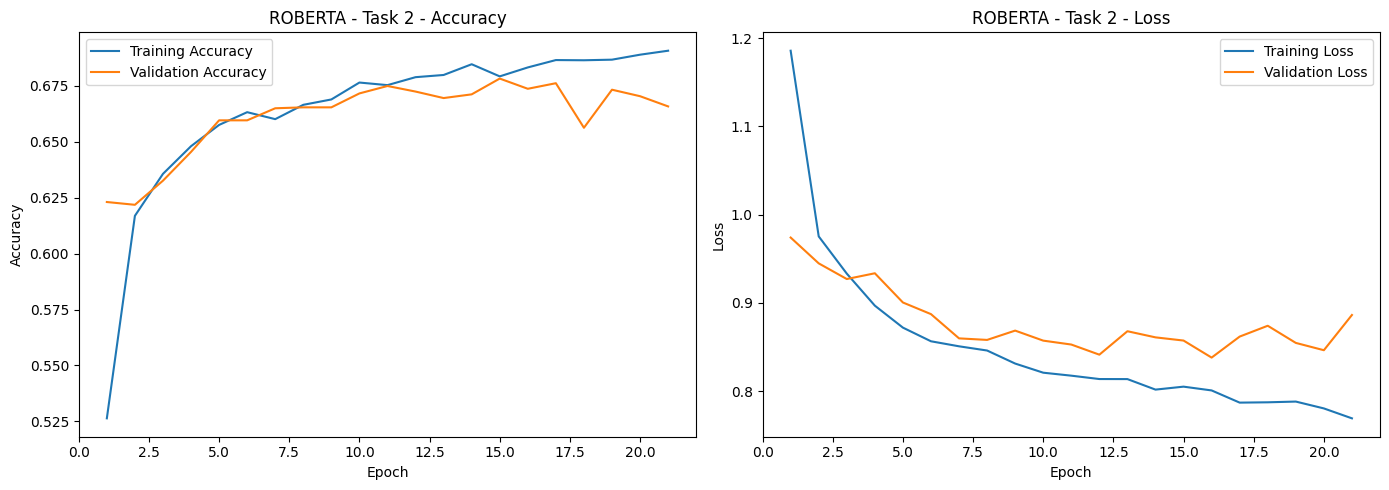

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Results for ROBERTA - Task 2
Accuracy : 0.6683
Precision: 0.6530
Recall   : 0.5697
F1-score : 0.5838


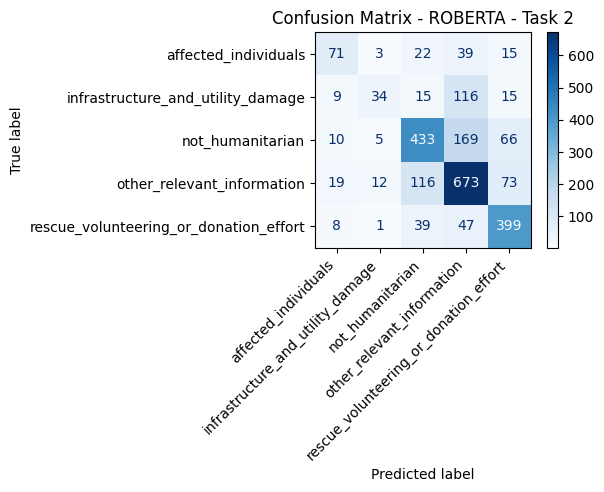

In [38]:
name = "roberta"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1,label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2,label_encoder=le_human)


🚀 Training MLP on BERTWEET embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7389 - loss: 0.5416 - val_accuracy: 0.7958 - val_loss: 0.4508
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7960 - loss: 0.4545 - val_accuracy: 0.8194 - val_loss: 0.4214
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8040 - loss: 0.4377 - val_accuracy: 0.8169 - val_loss: 0.4221
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8100 - loss: 0.4298 - val_accuracy: 0.8315 - val_loss: 0.4059
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8115 - loss: 0.4240 - val_accuracy: 0.8244 - val_loss: 0.4102
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8185 - loss: 0.4216 - val_accuracy: 0.8252 - val_loss: 0.4083
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8184 - loss: 0.4201 - val_accuracy: 0.8306 - val_loss: 0.4007
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - ac

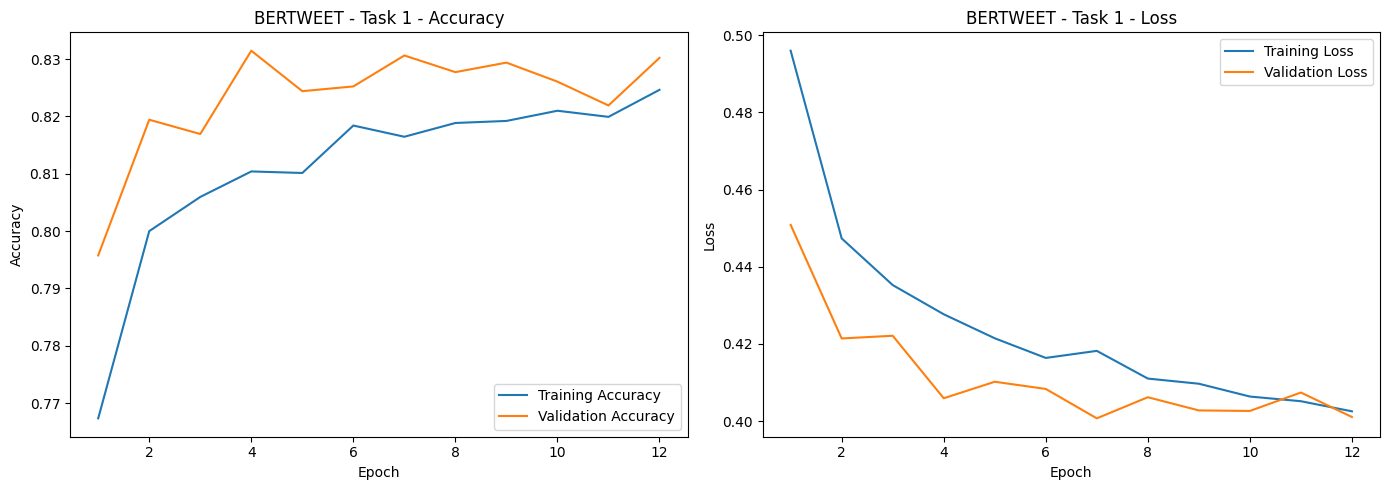

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

📊 Results for BERTWEET - Task 1
Accuracy : 0.8128
Precision: 0.7544
Recall   : 0.5037
F1-score : 0.6040


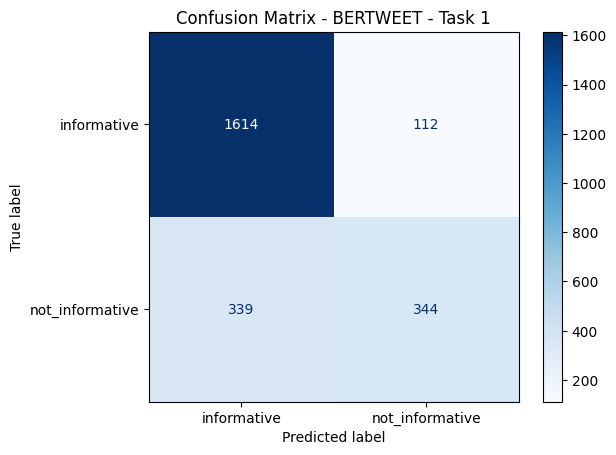


🚀 Training MLP on BERTWEET embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4751 - loss: 1.2904 - val_accuracy: 0.5940 - val_loss: 1.0295
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5950 - loss: 1.0283 - val_accuracy: 0.6119 - val_loss: 0.9822
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6129 - loss: 0.9718 - val_accuracy: 0.6443 - val_loss: 0.9296
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6225 - loss: 0.9439 - val_accuracy: 0.6517 - val_loss: 0.9130
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6307 - loss: 0.9284 - val_accuracy: 0.6418 - val_loss: 0.9344
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6319 - loss: 0.9161 - val_accuracy: 0.6447 - val_loss: 0.9106
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6411 - loss: 0.8954 - val_accuracy: 0.6538 - val_loss: 0.8997
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - ac

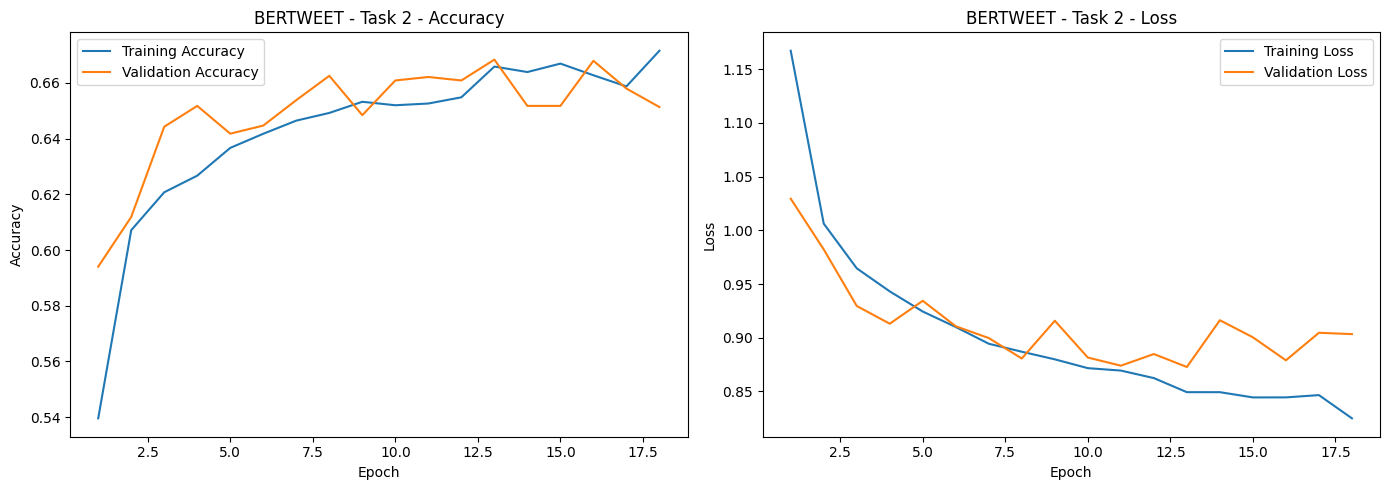

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

📊 Results for BERTWEET - Task 2
Accuracy : 0.6488
Precision: 0.6634
Recall   : 0.5425
F1-score : 0.5694


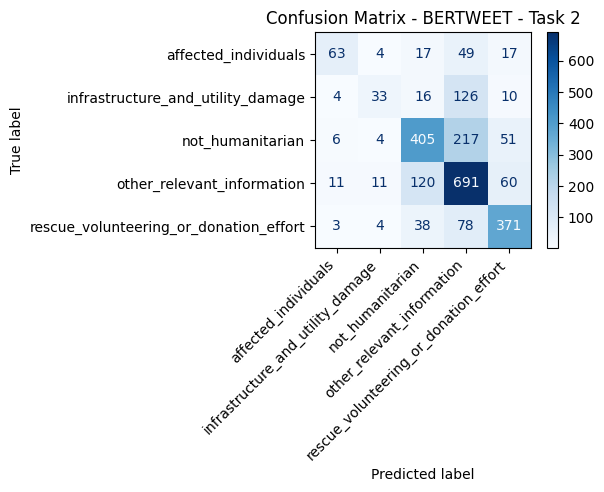

In [39]:
name = "bertweet"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)

## HuggingFace Models - Fine-Tuning

In [17]:
def compute_metrics(pred, is_binary=True):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    avg_type = 'binary' if is_binary else 'macro'
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average=avg_type, zero_division=0),
        'recall': recall_score(labels, preds, average=avg_type, zero_division=0),
        'f1': f1_score(labels, preds, average=avg_type, zero_division=0),
    }

def plot_loss_curves(trainer):
    log_history = trainer.state.log_history

    epochs = []
    train_losses = []
    val_losses = []

    for entry in log_history:
        if "loss" in entry and "epoch" in entry:
            train_losses.append(entry["loss"])
            epochs.append(entry["epoch"])
        if "eval_loss" in entry:
            val_losses.append(entry["eval_loss"])

    plt.plot(epochs, train_losses, label="Training Loss")
    if val_losses:
        plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Freeze primi `k` layer del modello transformer
def freeze_model_layers(model, num_freeze=6):
    try:
        encoder_layers = model.base_model.encoder.layer
        # ❄️ Congela i PRIMI num_freeze layer
        for i in range(num_freeze):
            for param in encoder_layers[i].parameters():
                param.requires_grad = False
        print(f"✅ Congelati i primi {num_freeze} layer.")

        # Sblocca anche la classification head
        if hasattr(model, "classifier"):
            for param in model.classifier.parameters():
                param.requires_grad = True
        elif hasattr(model, "score"):
            for param in model.score.parameters():
                param.requires_grad = True
        else:
            raise ValueError("Nessuna classification head trovata (classifier o score).")
        
        trained_params = count_trainable_parameters(model)
        print("Parametri allenabili: ", trained_params)

    except AttributeError:
        print("⚠️ Impossibile accedere ai layer encoder: modello non standard.")


def train_transformer_model(model_name, df_train, df_val, df_test, text_column, label_column, 
                            num_labels, task_name, freeze_layers=0, label_encoder=None):
    """
    Esegue fine-tuning di un transformer Hugging Face per una classificazione testuale.

    Args:
        model_name (str): es. 'bert-base-uncased', 'vinai/bertweet-base'
        df_train, df_val, df_test (DataFrame): contengono testo e label
        text_column (str): nome colonna testo
        label_column (str): nome colonna label (interi)
        num_labels (int): 2 (binario) o N classi
        task_name (str): "Task 1" o "Task 2"
    """

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    # Tokenizzazione
    def tokenize_fn(examples):
        return tokenizer(examples[text_column], truncation=True, padding=True, max_length=128)

    # Conversione a Dataset Hugging Face
    ds_train = Dataset.from_pandas(df_train[[text_column, label_column]])
    ds_val = Dataset.from_pandas(df_val[[text_column, label_column]])
    ds_test = Dataset.from_pandas(df_test[[text_column, label_column]])

    ds_train = ds_train.rename_column(label_column, "label")
    ds_val = ds_val.rename_column(label_column, "label")
    ds_test = ds_test.rename_column(label_column, "label")

    ds_train = ds_train.map(tokenize_fn, batched=True)
    ds_val = ds_val.map(tokenize_fn, batched=True)
    ds_test = ds_test.map(tokenize_fn, batched=True)

    # Modello
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    if freeze_layers > 0:
        freeze_model_layers(model, num_freeze=freeze_layers)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device) 
    
    # TrainingArguments
    training_args = TrainingArguments(
        output_dir=f"./model/{model_name}_{task_name}",
        logging_dir="./logs",
        logging_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        fp16=True,
        report_to=[],
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        compute_metrics=lambda p: compute_metrics(p, is_binary=(num_labels == 2)),
        tokenizer=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # Training
    trainer.train()
    
    # Salvataggio del modello fine-tunato e del tokenizer
    save_path = f"./model/{model_name}_{task_name}"
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)

    plot_loss_curves(trainer)
    
    # Valutazione su test set
    test_metrics = trainer.evaluate(ds_test)
    print(f"\n📊 Test metrics for {model_name} - {task_name}")
    for k, v in test_metrics.items():
        if k.startswith("eval_"):
            print(f"{k[5:]}: {v:.4f}")
    
    # Confusion Matrix
    preds_output = trainer.predict(ds_test)
    preds = np.argmax(preds_output.predictions, axis=1)
    labels = preds_output.label_ids

    # Classi leggibili per la confusion matrix
    if label_encoder is not None:
        class_names = label_encoder.classes_
    else:
        class_names = sorted(set(labels))  # fallback (numeri)

    # Plot
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix - {task_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return preds



In [11]:
def check_errors(X_test_raw, y_test, y_pred, label_encoder):
    y_test_str =  label_encoder.inverse_transform(y_test)
    y_pred_str = label_encoder.inverse_transform(y_pred)

    errors_df = pd.DataFrame({
        "text": X_test_raw,
        "true_label": y_test_str,
        "predicted_label": y_pred_str
    })

    # Filtra solo gli errori
    misclassified = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]
    return misclassified

In [12]:
text_train_df["text_info_encoded"] = train_labels_task1
text_val_df["text_info_encoded"] = val_labels_task1
text_test_df["text_info_encoded"] = test_labels_task1

text_train_df["text_human_encoded"] = train_labels_task2
text_val_df["text_human_encoded"] = val_labels_task2
text_test_df["text_human_encoded"] = test_labels_task2

text_train_df.head(5)

,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet,text_info_encoded,text_human_encoded
0,Trucking Companies Houston's Lifeline Surges I...,informative,rescue_volunteering_or_donation_effort,Trucking Companies Houston's Lifeline Surges I...,Trucking Companies Houston's Lifeline Surges I...,0,4
1,#Hurricane #Harvey damaged #ExxonMobil refiner...,informative,infrastructure_and_utility_damage,Hurricane Harvey damaged ExxonMobil refineries...,#Hurricane #Harvey damaged #ExxonMobil refiner...,0,1
2,Witness in former Mora superintendent's forger...,not_informative,not_humanitarian,Witness in former Mora superintendent's forger...,Witness in former Mora superintendent's forger...,1,2
3,Mexico earthquake: Many children killed at pri...,informative,affected_individuals,Mexico earthquake: Many children killed at pri...,Mexico earthquake: Many children killed at pri...,0,0
4,@KrollOntrack is offering discounted recoverie...,informative,rescue_volunteering_or_donation_effort,is offering discounted recoveries for hurrican...,@KrollOntrack is offering discounted recoverie...,0,4


In [13]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 2060


## BERTWEET

### NO FREEZE

In [ ]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    label_encoder=le_info
)

In [ ]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    label_encoder = le_human
)

### FREEZING

In [ ]:
model_name = "vinai/bertweet-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

In [ ]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    freeze_layers=10,
    label_encoder=le_info
)

In [ ]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    freeze_layers=10,
    label_encoder=le_human
)

## BERT CLASSICO

### NO FREEZE

In [ ]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    label_encoder=le_info
)

In [ ]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    label_encoder=le_human
)

### FREEZING

In [ ]:
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Numero totale layer: 12


In [ ]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    freeze_layers=10,
    label_encoder=le_info
)

In [ ]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    freeze_layers=10,
    label_encoder=le_human
)

## ROBERTA

### NO FREEZE

In [ ]:
train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    label_encoder=le_info
)

In [ ]:
train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    label_encoder=le_human
)

### FREEZING

In [10]:
model_name = "roberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Numero totale layer: 12


Map: 100%|██████████| 2409/2409 [00:00<00:00, 10426.92 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati i primi 10 layer.
Parametri allenabili:  53768450


 10%|█         | 352/3520 [01:04<09:33,  5.52it/s]

{'loss': 0.4557, 'grad_norm': 8.564547538757324, 'learning_rate': 1.800568181818182e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [01:08<09:33,  5.52it/s]

...

{'loss': 0.3069, 'grad_norm': 6.155003070831299, 'learning_rate': 6.0113636363636376e-06, 'epoch': 7.0}



 70%|███████   | 2464/3520 [08:14<03:14,  5.44it/s]

{'eval_loss': 0.3605562150478363, 'eval_accuracy': 0.8538812785388128, 'eval_precision': 0.8025594149908593, 'eval_recall': 0.6427525622254758, 'eval_f1': 0.7138211382113822, 'eval_runtime': 4.4385, 'eval_samples_per_second': 542.756, 'eval_steps_per_second': 17.123, 'epoch': 7.0}


 70%|███████   | 2464/3520 [08:16<03:32,  4.96it/s]


{'train_runtime': 496.5862, 'train_samples_per_second': 226.345, 'train_steps_per_second': 7.088, 'train_loss': 0.35462705191079674, 'epoch': 7.0}


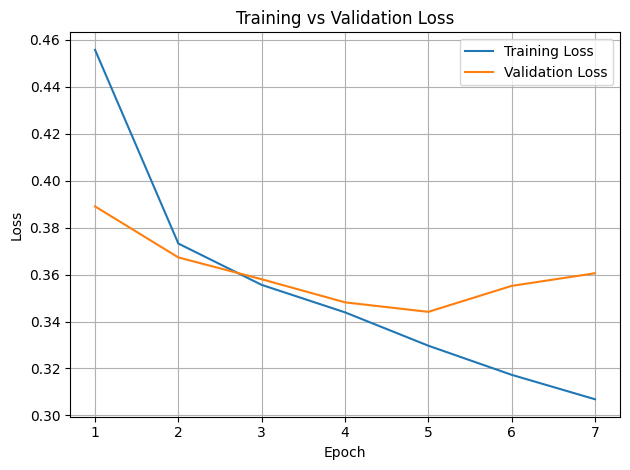

100%|██████████| 76/76 [00:04<00:00, 15.43it/s]



📊 Test metrics for roberta-base - Task1
loss: 0.4061
accuracy: 0.8315
precision: 0.7648
recall: 0.5857
f1: 0.6633
runtime: 5.0461
samples_per_second: 477.3970
steps_per_second: 15.0610


100%|██████████| 76/76 [00:04<00:00, 15.62it/s]


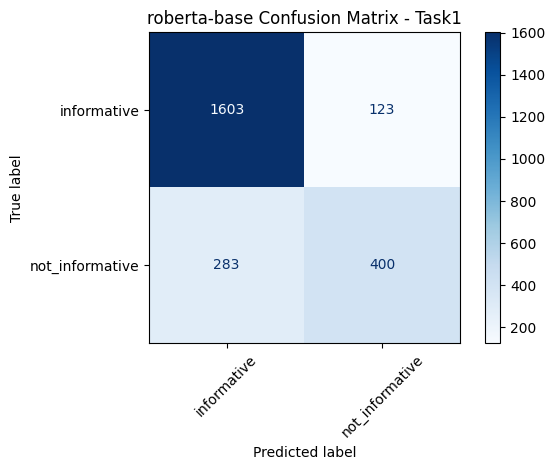

In [19]:
y_preds = train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task1",
    freeze_layers=10,
    label_encoder=le_info
)

In [ ]:
mis = check_errors(text_test_df["tweet_text"], text_test_df["text_info_encoded"], y_preds, le_info)

mis.head(10)

Map: 100%|██████████| 2409/2409 [00:00<00:00, 11473.60 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati i primi 10 layer.
Parametri allenabili:  53770757


 10%|█         | 352/3520 [01:01<09:19,  5.67it/s]

{'loss': 1.0349, 'grad_norm': 7.615558624267578, 'learning_rate': 1.8011363636363636e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [01:05<09:19,  5.67it/s]

...

{'loss': 0.6293, 'grad_norm': 14.051519393920898, 'learning_rate': 8.011363636363637e-06, 'epoch': 6.0}



 60%|██████    | 2112/3520 [06:45<04:14,  5.54it/s]

{'eval_loss': 0.7559572458267212, 'eval_accuracy': 0.7168949771689498, 'eval_precision': 0.6967497803044511, 'eval_recall': 0.7289311242047398, 'eval_f1': 0.7051012949052835, 'eval_runtime': 4.258, 'eval_samples_per_second': 565.764, 'eval_steps_per_second': 17.849, 'epoch': 6.0}


 60%|██████    | 2112/3520 [06:47<04:31,  5.18it/s]

{'train_runtime': 407.23, 'train_samples_per_second': 276.011, 'train_steps_per_second': 8.644, 'train_loss': 0.7416950572620739, 'epoch': 6.0}


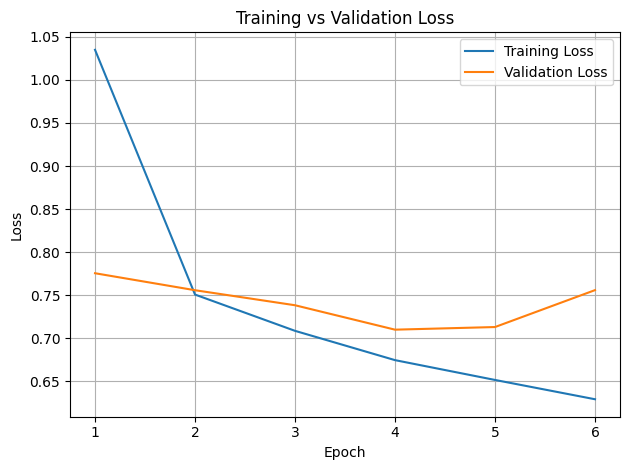

100%|██████████| 76/76 [00:04<00:00, 15.94it/s]



📊 Test metrics for roberta-base - Task2
loss: 0.7520
accuracy: 0.7011
precision: 0.6898
recall: 0.6774
f1: 0.6802
runtime: 4.8708
samples_per_second: 494.5750
steps_per_second: 15.6030


100%|██████████| 76/76 [00:04<00:00, 16.13it/s]


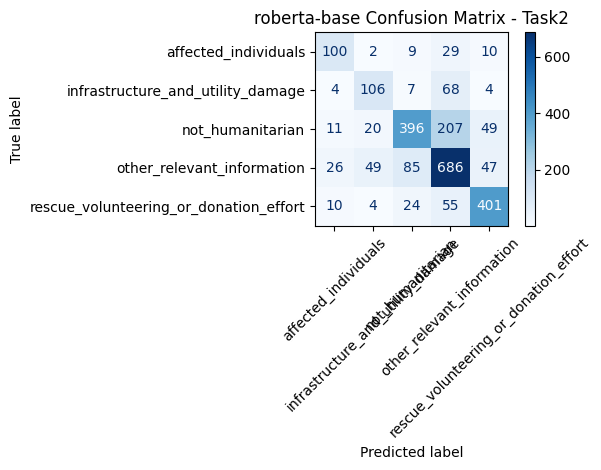

array([3, 3, 1, ..., 1, 2, 2], dtype=int64)

In [18]:
train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task2",
    freeze_layers=10,
    label_encoder=le_human
)